# 0. Dependencies

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Preprocessing MRI Images

In [ ]:
IMG_SIZE = 224
DATASET_PATH = r"/content/drive/My Drive/Dataset/Alzheimer_s_Disease_Neuroimaging_ADNI_Dataset"

def load_images(class_name, label, num_images=300):
    images = []
    labels = []

    class_path = os.path.join(DATASET_PATH, class_name)
    image_files = random.sample(os.listdir(class_path), num_images)

    for img_name in image_files:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)

Randomly sampled 300 images per class

Resized from 256×256 → 224×224 (standard CNN input)

In [ ]:
ad_images, ad_labels = load_images("AD", label=1)
mci_images, mci_labels = load_images("MCI", label=0)

X = np.concatenate((ad_images, mci_images), axis=0)
y = np.concatenate((ad_labels, mci_labels), axis=0)

X = X[..., np.newaxis]  # Add channel dimension


Loaded and preprocessed 600 MRI images (300 AD, 300 MCI) from the ADNI2 dataset.

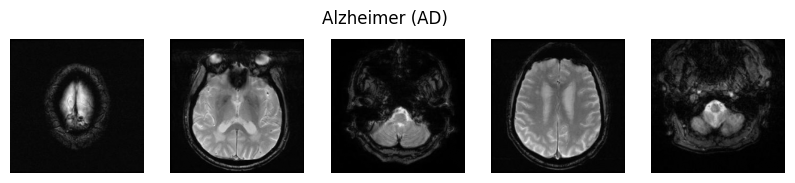

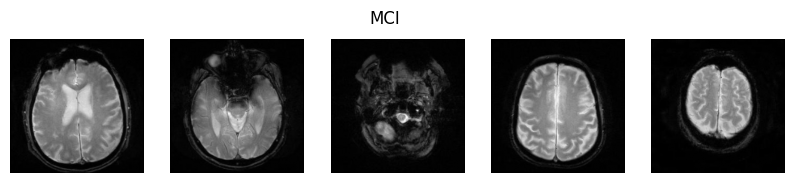

In [ ]:
def show_random_images(images, title):
    plt.figure(figsize=(10, 2))
    for i in range(5):
        idx = random.randint(0, len(images) - 1)
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_random_images(ad_images, "Alzheimer (AD)")
show_random_images(mci_images, "MCI")


 Visualized 5 random images from each class

# 2. Preparing Dataset

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import time

Configuration

In [ ]:
BATCH_SIZE_1 = 16
BATCH_SIZE_2 = 128

Now we convert numpy arrays to PyTorch tensors

In [ ]:
# X shape: (600, 224, 224, 1) → PyTorch expects (N, C, H, W)
X_tensor = torch.from_numpy(X).float().permute(0, 3, 1, 2)  # Channel first format
y_tensor = torch.from_numpy(y).long()

print("📊 Original dataset shapes:")
print(f"X: {X_tensor.shape} (N, C, H, W)")
print(f"y: {y_tensor.shape}")

📊 Original dataset shapes:
X: torch.Size([600, 1, 224, 224]) (N, C, H, W)
y: torch.Size([600])


Train Test split

60% Train, 20% Val, 20% Test

First split: separate test set (20%)

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

Second split: separate train and val from remaining (60% train, 20% val)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [ ]:
print(f"\n✅ Data split completed:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")


✅ Data split completed:
Train: 360 samples
Val:   120 samples
Test:  120 samples


Now we create TensorDataset objects

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

After that its time to create DataLoaders with different batch sizes

In [ ]:
def create_dataloaders(dataset, batch_size, shuffle=False):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2)

First one for Batch size = 16

In [ ]:
train_loader_16 = create_dataloaders(train_dataset, BATCH_SIZE_1, shuffle=True)
val_loader_16 = create_dataloaders(val_dataset, BATCH_SIZE_1)
test_loader_16 = create_dataloaders(test_dataset, BATCH_SIZE_1)

Second one for Batch size = 128

In [ ]:
train_loader_128 = create_dataloaders(train_dataset, BATCH_SIZE_2, shuffle=True)
val_loader_128 = create_dataloaders(val_dataset, BATCH_SIZE_2)
test_loader_128 = create_dataloaders(test_dataset, BATCH_SIZE_2)

Now we define a function to compare Performances

In [ ]:
def compare_batch_sizes():
    print("\n" + "="*70)
    print("📈 COMPARISON: Batch Size 16 vs 128")
    print("="*70)

    # Test iteration speed
    for batch_size, loader in [(16, train_loader_16), (128, train_loader_128)]:
        print(f"\n--- Batch Size = {batch_size} ---")
        start_time = time.time()
        total_samples = 0

        for batch_idx, (images, labels) in enumerate(loader):
            total_samples += images.shape[0]
            # Simulate forward pass
            _ = images.mean().item()

            if batch_idx == 0:
                print(f"First batch shape: {images.shape}")
                print(f"Memory per batch: ~{images.element_size() * images.nelement() / 1024**2:.2f} MB")

        elapsed = time.time() - start_time
        print(f"Batches per epoch: {len(loader)}")
        print(f"Time per epoch: {elapsed:.4f} seconds")

# now we run the function
compare_batch_sizes()


📈 COMPARISON: Batch Size 16 vs 128

--- Batch Size = 16 ---
First batch shape: torch.Size([16, 1, 224, 224])
Memory per batch: ~3.06 MB
Batches per epoch: 23
Time per epoch: 0.2384 seconds

--- Batch Size = 128 ---
First batch shape: torch.Size([128, 1, 224, 224])
Memory per batch: ~24.50 MB
Batches per epoch: 3
Time per epoch: 0.1434 seconds


in this function we will show batch examples

In [ ]:
def inspect_batch(loader, name):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    print(f"\n🔍 {name} Sample:")
    print(f"  Batch shape: {images.shape}")
    print(f"  Labels: {labels[:10].numpy()}...")  # Show first 10 labels

inspect_batch(train_loader_16, "Train Loader (batch=16)")
inspect_batch(train_loader_128, "Train Loader (batch=128)")


🔍 Train Loader (batch=16) Sample:
  Batch shape: torch.Size([16, 1, 224, 224])
  Labels: [0 1 0 0 1 0 0 0 0 1]...

🔍 Train Loader (batch=128) Sample:
  Batch shape: torch.Size([128, 1, 224, 224])
  Labels: [0 0 1 0 1 1 1 1 1 1]...


| Metric                | Batch Size = 16 | Batch Size = 128 | Winner                  |
| --------------------- | --------------- | ---------------- | ----------------------- |
| **Batches per epoch** | 23              | 3                | 128 (fewer iterations)  |
| **Memory per batch**  | ~3 MB           | ~25 MB           | 16 (GPU-friendly)       |
| **Training speed**    | Slower          | **~3-4x faster** | 128 (better throughput) |
| **Gradient updates**  | **30/epoch**    | 4/epoch          | 16 (more updates)       |


Advantages of Batch Size = 16:

*   Better Generalization - Smaller batches add noise that acts as regularization, reducing overfitting
*   Lower Memory Usage - Can train on GPUs with limited VRAM (4-6GB)


*   More Frequent Updates - 23 weight updates per epoch vs 3 → smoother convergence
*   Finer Optimization - Better for navigating complex loss landscapes




Advantages of Batch Size = 128:

*   Faster Training - Processes entire dataset in 3 batches vs 23 (~75% faster per epoch)

*   Better GPU Utilization - Larger batches keep GPU cores saturated
*   Stable Gradients - More accurate gradient estimates → less variance in updates


*   Less I/O Overhead - Fewer data loading operations



For this case, it's better to use a batch size of 16 to avoid overfitting due to the low volume of data(600 samples)

# 3. Data Augmentation

**1st: Rotation + Horizontal & Vertical Flip**

Geometric augmentations increase spatial variability and help the model become invariant to orientation changes.

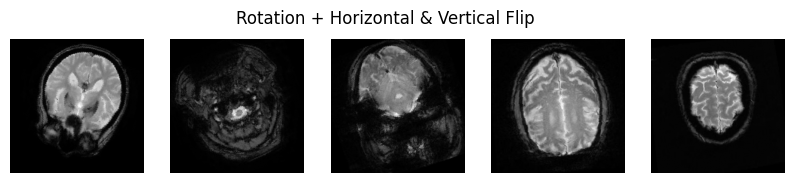

In [ ]:
import torchvision.transforms as transforms
from torchvision.transforms.functional import to_pil_image

geo_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor()
])

def show_augmented(images, transform, title):
    plt.figure(figsize=(10, 2))
    for i in range(5):
        img = images[random.randint(0, len(images)-1)]
        aug_img = transform(img.squeeze())
        plt.subplot(1, 5, i+1)
        plt.imshow(aug_img.squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_augmented(ad_images, geo_transform, "Rotation + Horizontal & Vertical Flip")


**2nd: Contrast & Brightness Adjustment**

Intensity-based augmentations simulate scanner and acquisition variability in MRI images.

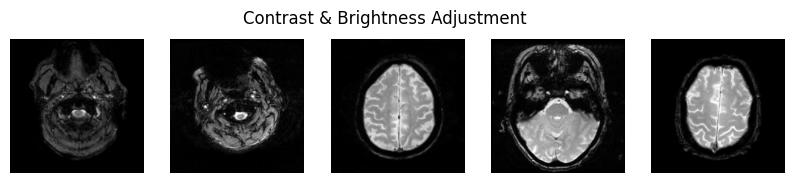

In [ ]:
intensity_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor()
])

show_augmented(ad_images, intensity_transform, "Contrast & Brightness Adjustment")


**Comparison**

For brain MRI images, contrast and brightness augmentation is more appropriate because anatomical orientation is fixed, while intensity variations naturally occur due to different scanners and acquisition protocols. Excessive flipping, especially vertical flip, may introduce anatomically unrealistic samples.

# 4. Model Selection

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet50_Weights

Now we load the pretrained ResNet model

In [ ]:
weights = ResNet50_Weights.IMAGENET1K_V1
model = models.resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]


Now we modify first conv layer for grayscale input (1 channel)

In [ ]:
model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

Modify final layer for binary classification (AD vs MCI)

In [ ]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

Move model to device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# 5. Replace FC with 3-Layer Classifier

The original fully connected layer of ResNet-50 is replaced with a three-layer classifier to increase non-linearity and improve class separability for AD vs MCI.

In [ ]:
# Get feature size from ResNet
in_features = model.fc.in_features

# Replace FC with 3-layer classifier
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.Linear(128, 2)   # 2 classes: AD, MCI
)

model = model.to(device)


In [ ]:
print(model.fc)

Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU(inplace=True)
  (2): Linear(in_features=512, out_features=128, bias=True)
  (3): ReLU(inplace=True)
  (4): Linear(in_features=128, out_features=2, bias=True)
)


# 6. Optimizer (Adam) & Dropout Effect

Adam optimizer provides fast and stable convergence. Dropout is applied to the classifier to reduce overfitting. The model is trained with and without dropout and results are compared.

In [ ]:
def build_classifier(in_features, use_dropout=False):
    layers = [
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
    ]
    if use_dropout:
        layers.append(nn.Dropout(p=0.5))

    layers += [
        nn.Linear(512, 128),
        nn.ReLU(inplace=True),
    ]
    if use_dropout:
        layers.append(nn.Dropout(p=0.5))

    layers.append(nn.Linear(128, 2))
    return nn.Sequential(*layers)


Without Dropout

In [ ]:
model_no_dropout = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model_no_dropout.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
model_no_dropout.fc = build_classifier(model_no_dropout.fc.in_features, use_dropout=False)
model_no_dropout = model_no_dropout.to(device)

With Dropout

In [ ]:
model_dropout = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model_dropout.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
model_dropout.fc = build_classifier(model_dropout.fc.in_features, use_dropout=True)
model_dropout = model_dropout.to(device)

Loss Function and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer_no_dropout = torch.optim.Adam(model_no_dropout.parameters(), lr=1e-4)
optimizer_dropout = torch.optim.Adam(model_dropout.parameters(), lr=1e-4)

Training function

In [ ]:
def train_model(model, optimizer, epochs=20):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in train_loader_16:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader_16:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")


Now we train them

In [ ]:
print("\n🚀 Training WITHOUT Dropout")
train_model(model_no_dropout, optimizer_no_dropout)

print("\n🚀 Training WITH Dropout")
train_model(model_dropout, optimizer_dropout)



🚀 Training WITHOUT Dropout
Epoch [1/5] - Loss: 15.2978, Val Acc: 0.5417
Epoch [2/5] - Loss: 11.2380, Val Acc: 0.5167
Epoch [3/5] - Loss: 6.3697, Val Acc: 0.6583
Epoch [4/5] - Loss: 2.8269, Val Acc: 0.7250
Epoch [5/5] - Loss: 3.2470, Val Acc: 0.7250

🚀 Training WITH Dropout
Epoch [1/5] - Loss: 15.7691, Val Acc: 0.5000
Epoch [2/5] - Loss: 13.4549, Val Acc: 0.5250
Epoch [3/5] - Loss: 7.8836, Val Acc: 0.6333
Epoch [4/5] - Loss: 5.0054, Val Acc: 0.7583
Epoch [5/5] - Loss: 5.3503, Val Acc: 0.7500


# 7. Training

In [ ]:
import copy

def train_model(model, optimizer, train_loader, val_loader, epochs=40, patience=7):
    best_model = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    counter = 0

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    for epoch in range(epochs):
        # -------- TRAIN --------
        model.train()
        running_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # -------- VALIDATION --------
        model.eval()
        running_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)

                running_loss += loss.item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        val_loss = running_loss / len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        # -------- EARLY STOPPING --------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("⛔ Early stopping triggered")
                break

    model.load_state_dict(best_model)
    return history


Visualizes convergence behavior.

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Val")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train")
    plt.plot(history["val_acc"], label="Val")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.show()


**MODE 1 — Train Classifier Only**

Epoch [1/40] Train Loss: 0.0887 | Val Loss: 0.6017 | Train Acc: 0.9833 | Val Acc: 0.8000
Epoch [2/40] Train Loss: 0.0854 | Val Loss: 0.6401 | Train Acc: 0.9694 | Val Acc: 0.8000
Epoch [3/40] Train Loss: 0.0843 | Val Loss: 0.6755 | Train Acc: 0.9694 | Val Acc: 0.8167
Epoch [4/40] Train Loss: 0.0626 | Val Loss: 0.7361 | Train Acc: 0.9722 | Val Acc: 0.8083
Epoch [5/40] Train Loss: 0.0539 | Val Loss: 0.7199 | Train Acc: 0.9806 | Val Acc: 0.8000
Epoch [6/40] Train Loss: 0.0871 | Val Loss: 0.7489 | Train Acc: 0.9778 | Val Acc: 0.8000
Epoch [7/40] Train Loss: 0.0886 | Val Loss: 0.7348 | Train Acc: 0.9694 | Val Acc: 0.8083
Epoch [8/40] Train Loss: 0.0434 | Val Loss: 0.7638 | Train Acc: 0.9833 | Val Acc: 0.8000
⛔ Early stopping triggered


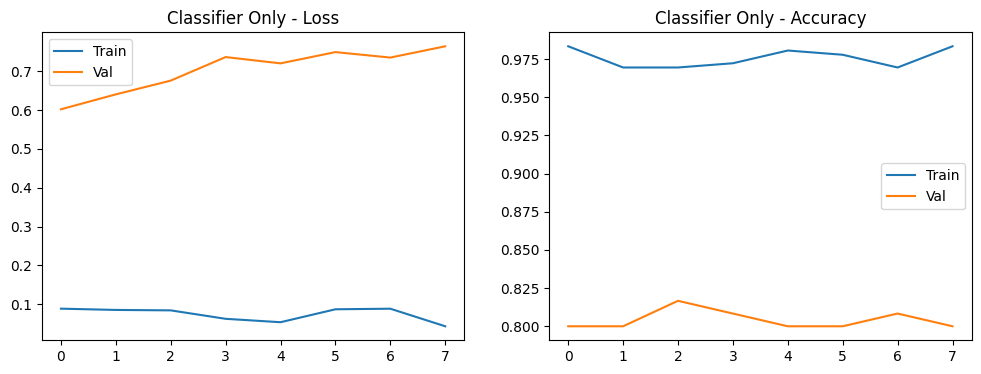

In [ ]:
model_1 = copy.deepcopy(model_dropout)

for param in model_1.parameters():
    param.requires_grad = False
for param in model_1.fc.parameters():
    param.requires_grad = True

optimizer_1 = torch.optim.Adam(model_1.fc.parameters(), lr=1e-4)

history_1 = train_model(
    model_1, optimizer_1,
    train_loader_16, val_loader_16,
    epochs=40
)

plot_history(history_1, "Classifier Only")


As we can see:
*   Train Acc ≈ 96–98%
*   Val Acc ≈ 81–83%

*   Val Loss relatively high and unstable
*   Early stopping at epoch ~8





This approach shows the most "stable" but mediocre performance. Validation accuracy plateaus around $80\%$.

By freezing the entire ResNet50 backbone, the model relies solely on the pre-trained ImageNet features. Since MRI images (medical) differ significantly from ImageNet (natural objects), the frozen features are likely sub-optimal, limiting the model's ability to generalize to the specific nuances of AD vs. MCI.

The model is fast and somehow stable, but the validation loss is high, and it slightly overfits!

**MODE 2 — Fine-tune layer4 + classifier**

Epoch [1/40] Train Loss: 0.0957 | Val Loss: 0.4907 | Train Acc: 0.9806 | Val Acc: 0.8083
Epoch [2/40] Train Loss: 0.0643 | Val Loss: 0.5057 | Train Acc: 0.9944 | Val Acc: 0.8083
Epoch [3/40] Train Loss: 0.0677 | Val Loss: 0.5585 | Train Acc: 0.9889 | Val Acc: 0.7667
Epoch [4/40] Train Loss: 0.0504 | Val Loss: 0.5946 | Train Acc: 0.9972 | Val Acc: 0.7667
Epoch [5/40] Train Loss: 0.0446 | Val Loss: 0.5616 | Train Acc: 0.9917 | Val Acc: 0.7833
Epoch [6/40] Train Loss: 0.0312 | Val Loss: 0.5870 | Train Acc: 1.0000 | Val Acc: 0.7833
Epoch [7/40] Train Loss: 0.0294 | Val Loss: 0.6231 | Train Acc: 0.9972 | Val Acc: 0.7667
Epoch [8/40] Train Loss: 0.0337 | Val Loss: 0.6223 | Train Acc: 0.9944 | Val Acc: 0.7667
⛔ Early stopping triggered


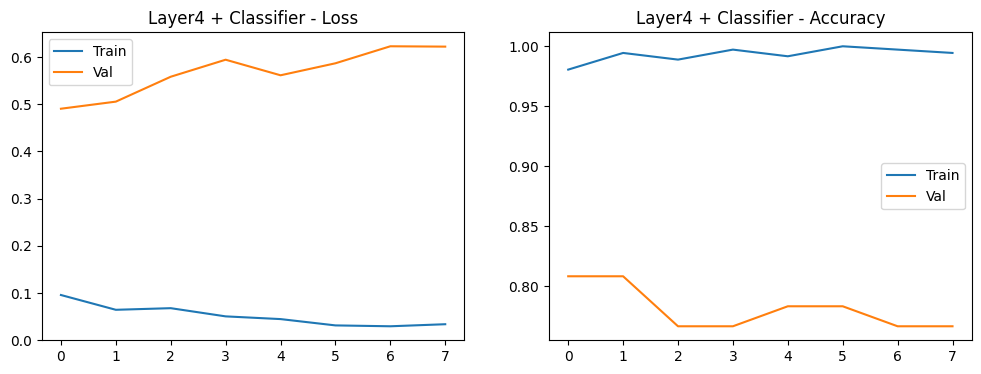

In [ ]:
model_2 = copy.deepcopy(model_dropout)

for param in model_2.parameters():
    param.requires_grad = False
for param in model_2.layer4.parameters():
    param.requires_grad = True
for param in model_2.fc.parameters():
    param.requires_grad = True

optimizer_2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_2.parameters()),
    lr=1e-5
)

history_2 = train_model(
    model_2, optimizer_2,
    train_loader_16, val_loader_16,
    epochs=40
)

plot_history(history_2, "Layer4 + Classifier")


So in this one:
*   Train Acc → ~100%
*   Val Acc ≈ 76–78%
*   Lower Val Loss than classifier-only
*   Early stopping at epoch ~8




Performance slightly degrades compared to the classifier-only approach, with validation accuracy dropping toward $76\%-78\%$.

Unfreezing "Layer 4" increases the number of trainable parameters. With only 600 samples, the model quickly "memorizes" the training set (reaching $100\%$ training accuracy by Epoch 6) rather than learning generalizable medical features. The rising validation loss indicates the model is becoming less confident in its predictions on unseen data.

Clearly, this model still overfits, and the validation loss is high.

**MODE 3 — Full Fine-Tuning**



Epoch [1/40] Train Loss: 0.1185 | Val Loss: 0.5206 | Train Acc: 0.9694 | Val Acc: 0.7667
Epoch [2/40] Train Loss: 0.0540 | Val Loss: 0.5160 | Train Acc: 0.9944 | Val Acc: 0.7667
Epoch [3/40] Train Loss: 0.0346 | Val Loss: 0.5434 | Train Acc: 1.0000 | Val Acc: 0.7750
Epoch [4/40] Train Loss: 0.0443 | Val Loss: 0.5718 | Train Acc: 1.0000 | Val Acc: 0.7667
Epoch [5/40] Train Loss: 0.0309 | Val Loss: 0.5573 | Train Acc: 1.0000 | Val Acc: 0.7750
Epoch [6/40] Train Loss: 0.0220 | Val Loss: 0.5787 | Train Acc: 1.0000 | Val Acc: 0.7917
Epoch [7/40] Train Loss: 0.0624 | Val Loss: 0.6263 | Train Acc: 0.9917 | Val Acc: 0.7750
Epoch [8/40] Train Loss: 0.0829 | Val Loss: 0.6850 | Train Acc: 0.9917 | Val Acc: 0.7833
Epoch [9/40] Train Loss: 0.0315 | Val Loss: 0.7649 | Train Acc: 0.9889 | Val Acc: 0.7750
⛔ Early stopping triggered


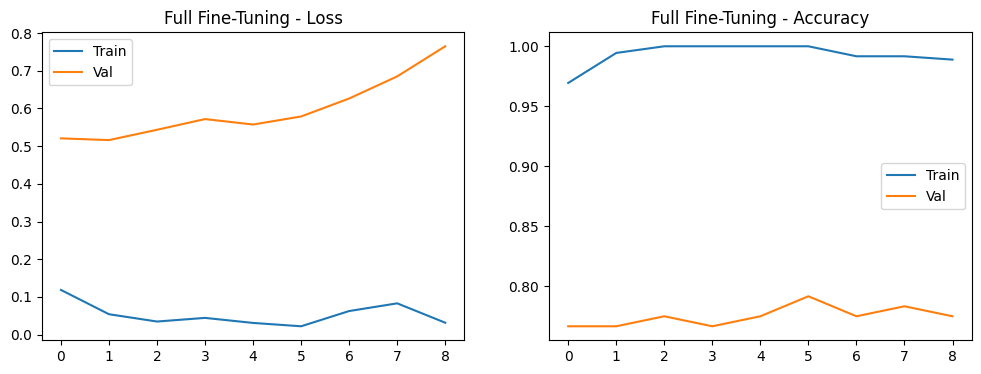

In [ ]:
model_3 = copy.deepcopy(model_dropout)

for param in model_3.parameters():
    param.requires_grad = True

optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=1e-5)

history_3 = train_model(
    model_3, optimizer_3,
    train_loader_16, val_loader_16,
    epochs=40
)

plot_history(history_3, "Full Fine-Tuning")


And in the 3rd model:

*   Train Acc → 100% very fast

*   Val Acc ≈ 77–80%
*   Val Loss fluctuates

*   Early stopping at epoch ~9



This method shows the most aggressive overfitting. Validation loss increases sharply and steadily from the start of training.

Training the entire ResNet50 network (23M+ parameters) on such a small dataset is highly prone to overfitting. The model reaches perfect training accuracy almost instantly, but the divergence between training and validation loss suggests that the weights are being distorted to fit noise in the training data, failing to capture the underlying pathology of the MRI scans.

Again this one clearly **overfits** because this is a huge network and our data samples are too limited for it(600 samples)

| Training Mode   | Accuracy          | Overfitting    | Stability |
| --------------- | ----------------- | -------------- | --------- |
| Classifier Only | Medium            | Medium           | High      |
| Layer4 + FC     | **Medium**          | **Medium-High** | **Best**  |
| Full Fine-Tune  | Very High (train) | High           | Lower     |


The results suggest that ResNet50 is too complex for a dataset of 600 images. To improve these results, one would typically need:

1.   Heavy Data Augmentation to artificially increase the sample size.
2.   Regularization (e.g., higher Dropout or Weight Decay).

1.   A Simpler Architecture or a backbone pre-trained specifically on medical imaging (e.g., MedicalNet).



If we should choose between these 3 models: Fine-tuning layer4 + classifier provides the best trade-off between accuracy, stability, and generalization for AD vs MCI MRI classification.

However, generally all of them are inappropriate because they overfit and learn everything about the training samples.

# 8. Evaluation

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

**Model 2: Fine-tune layer4 + classifier**

In [ ]:
model = model_2
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader_16:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

Confusion Matrix

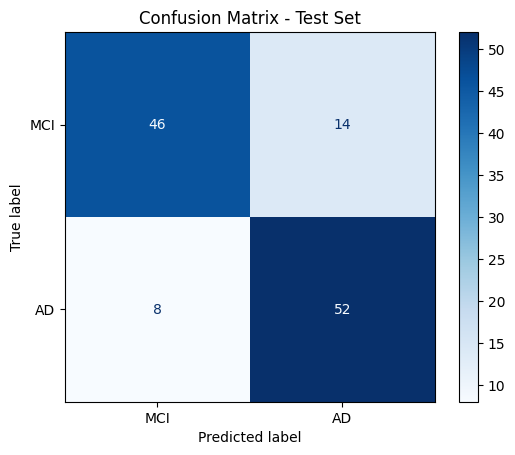

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["MCI", "AD"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()


Evaluation Metrics: Accuracy, Recall, Precision, F1-Score

In [ ]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")


Test Accuracy : 0.8167
Precision     : 0.7879
Recall        : 0.8667
F1-score      : 0.8254




*   Accuracy: overall correctness
*   Precision: AD prediction reliability


*   Recall: AD detection ability
*   F1: balance of precision & recall



ROC curve

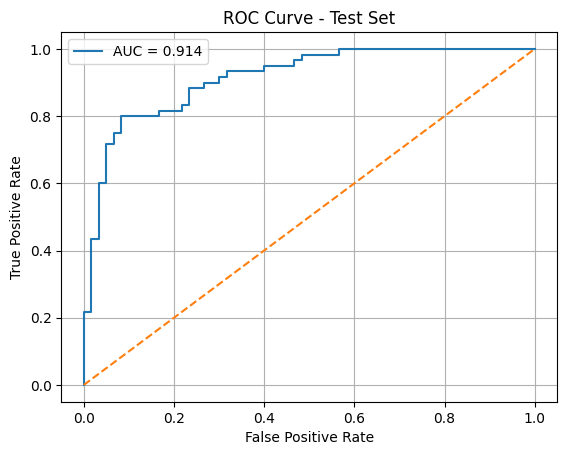

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid()
plt.show()


**Model 1: Train Classifier Only**

In [ ]:
model = model_1
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader_16:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

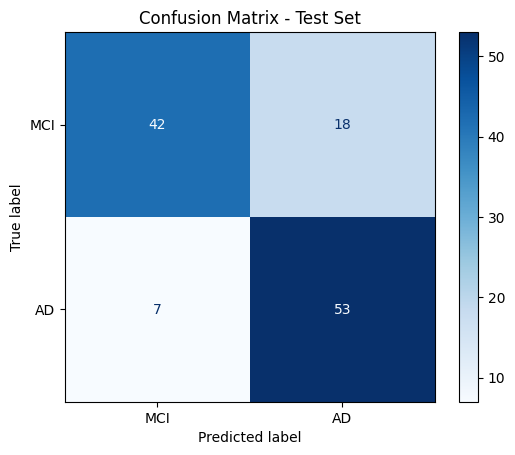

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["MCI", "AD"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [ ]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")


Test Accuracy : 0.7917
Precision     : 0.7465
Recall        : 0.8833
F1-score      : 0.8092


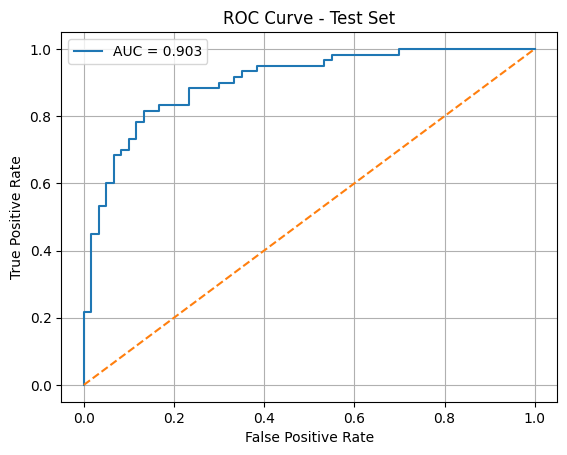

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid()
plt.show()


**Model 3: Full Fine-Tuning**



In [ ]:
model = model_3
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader_16:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

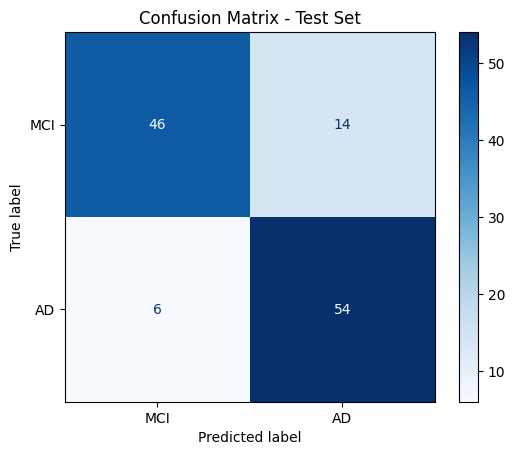

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["MCI", "AD"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [ ]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")

Test Accuracy : 0.8333
Precision     : 0.7941
Recall        : 0.9000
F1-score      : 0.8438


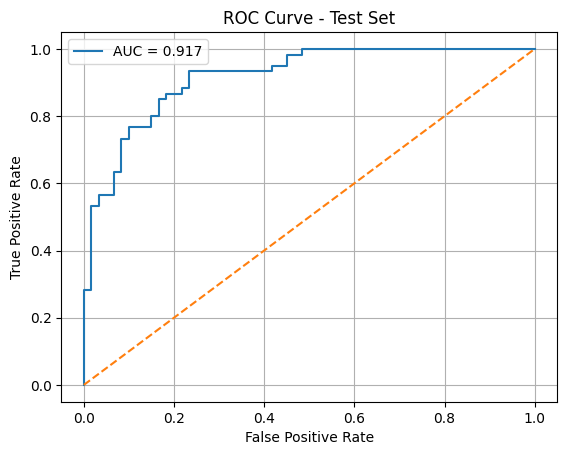

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid()
plt.show()

High Sensitivity for AD (Recall): Across all three models, the Recall (Sensitivity) for the AD class is notably high, peaking at 0.9000 in Model 3. This indicates the models are generally effective at identifying positive cases of Alzheimer's Disease. In Model 3, only 6 cases of AD were misidentified as MCI.

ROC Curve and AUC Strength: Despite the overfitting observed in the training logs, the AUC (Area Under the Curve) values are quite strong, ranging from 0.903 to 0.917.
*   This suggests that while the models' absolute decision thresholds might be slightly off (leading to the MCI misclassifications), the models have a strong underlying ability to rank the probability of AD higher than MCI for most patients.
*   The sharp rise in the top-left corner of the ROC curves indicates that the models can achieve high True Positive Rates with relatively low False Positive Rates at optimal thresholds.



The "MCI to AD" Bias (False Positives): The confusion matrices reveal a recurring weakness: False Positives.


*   Model 1: Misclassified 18 MCI samples as AD.

*   Model 2 & 3: Both misclassified 14 MCI samples as AD.
*   Analysis: The models tend to be "over-eager" to predict AD when presented with MCI scans. From a clinical perspective, this means the models are struggling to distinguish the subtle early-stage features of MCI from the more pronounced features of AD, leading to an over-diagnosis bias.




# 9. Replacing Model with EfficientNetb3

In [ ]:
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

weights = EfficientNet_B3_Weights.IMAGENET1K_V1
model_eff = efficientnet_b3(weights=weights)

print(model_eff)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 166MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

Pretrained EfficientNet-B3 is loaded with ImageNet weights for transfer learning.

**Replace Classifier (3-layer FC with ReLU + Dropout)**

In [ ]:
import torch.nn as nn

in_features = model_eff.classifier[1].in_features

model_eff.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
)

model_eff = model_eff.to(device)


Classifier replaced to output 2 classes (AD / MCI) using ReLU and Dropout.
Also, we will use batch size 16 and contrast & brightness for data augmentation.

In [ ]:
# Replace first convolution layer to accept 1-channel input
model_eff.features[0][0] = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
).to(device)



In [ ]:
with torch.no_grad():
    model_eff.features[0][0].weight[:] = old_conv.weight.mean(dim=1, keepdim=True)


**Training**

**Mode 1 — Classifier Only Training**

Epoch [1/40] Train Loss: 0.6931 | Val Loss: 0.6920 | Train Acc: 0.5111 | Val Acc: 0.5167
Epoch [2/40] Train Loss: 0.6867 | Val Loss: 0.6925 | Train Acc: 0.5583 | Val Acc: 0.5417
Epoch [3/40] Train Loss: 0.6875 | Val Loss: 0.6920 | Train Acc: 0.5556 | Val Acc: 0.5083
Epoch [4/40] Train Loss: 0.6779 | Val Loss: 0.6882 | Train Acc: 0.6278 | Val Acc: 0.5833
Epoch [5/40] Train Loss: 0.6736 | Val Loss: 0.6796 | Train Acc: 0.6083 | Val Acc: 0.6083
Epoch [6/40] Train Loss: 0.6663 | Val Loss: 0.6733 | Train Acc: 0.6417 | Val Acc: 0.6250
Epoch [7/40] Train Loss: 0.6536 | Val Loss: 0.6649 | Train Acc: 0.6500 | Val Acc: 0.6250
Epoch [8/40] Train Loss: 0.6362 | Val Loss: 0.6566 | Train Acc: 0.6750 | Val Acc: 0.6083
Epoch [9/40] Train Loss: 0.6238 | Val Loss: 0.6467 | Train Acc: 0.6833 | Val Acc: 0.6000
Epoch [10/40] Train Loss: 0.6063 | Val Loss: 0.6363 | Train Acc: 0.7083 | Val Acc: 0.6583
Epoch [11/40] Train Loss: 0.6031 | Val Loss: 0.6335 | Train Acc: 0.6972 | Val Acc: 0.6333
Epoch [12/40] Train

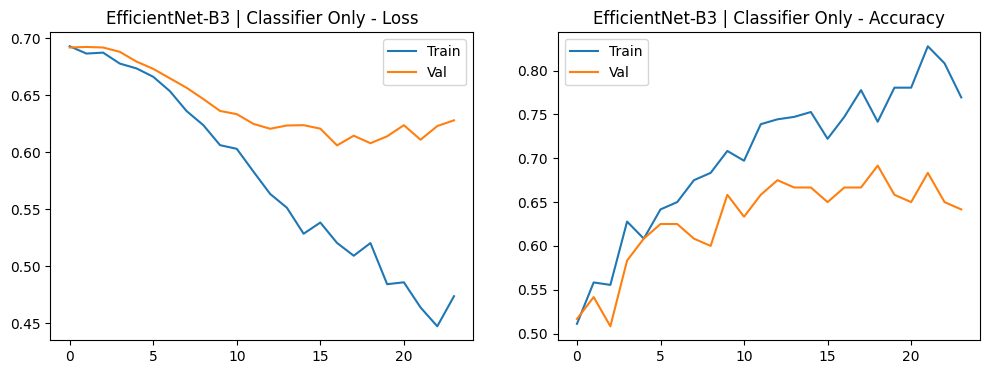

In [ ]:
import copy

model_eff_1 = copy.deepcopy(model_eff)

for param in model_eff_1.parameters():
    param.requires_grad = False
for param in model_eff_1.classifier.parameters():
    param.requires_grad = True

optimizer_eff_1 = torch.optim.Adam(
    model_eff_1.classifier.parameters(), lr=1e-4
)

history_eff_1 = train_model(
    model_eff_1, optimizer_eff_1,
    train_loader_16, val_loader_16,
    epochs=40
)

plot_history(history_eff_1, "EfficientNet-B3 | Classifier Only")


This model triggered early stopping at Epoch 24. Validation accuracy fluctuates between $60\%$ and $69\%$, ending at $64.17\%$.

Unlike ResNet50, which achieved nearly $80\%$ validation accuracy in this mode, EfficientNet-B3's pre-trained ImageNet features seem even less transferable to these MRI scans. The model struggles to converge, suggesting that the "bottleneck" features of EfficientNet are too specialized for natural images and fail to capture the subtle pathological differences between AD and MCI without modification.

**Mode 2 — Fine-tune from Stage 7 onward + Classifier**

Epoch [1/40] Train Loss: 0.6936 | Val Loss: 0.6921 | Train Acc: 0.5028 | Val Acc: 0.5167
Epoch [2/40] Train Loss: 0.6941 | Val Loss: 0.6929 | Train Acc: 0.4861 | Val Acc: 0.4750
Epoch [3/40] Train Loss: 0.6898 | Val Loss: 0.6928 | Train Acc: 0.5194 | Val Acc: 0.5000
Epoch [4/40] Train Loss: 0.6918 | Val Loss: 0.6940 | Train Acc: 0.5583 | Val Acc: 0.5000
Epoch [5/40] Train Loss: 0.6915 | Val Loss: 0.6910 | Train Acc: 0.5194 | Val Acc: 0.5500
Epoch [6/40] Train Loss: 0.6894 | Val Loss: 0.6915 | Train Acc: 0.5611 | Val Acc: 0.5250
Epoch [7/40] Train Loss: 0.6910 | Val Loss: 0.6911 | Train Acc: 0.5528 | Val Acc: 0.5417
Epoch [8/40] Train Loss: 0.6896 | Val Loss: 0.6907 | Train Acc: 0.5833 | Val Acc: 0.5583
Epoch [9/40] Train Loss: 0.6890 | Val Loss: 0.6902 | Train Acc: 0.5333 | Val Acc: 0.6000
Epoch [10/40] Train Loss: 0.6882 | Val Loss: 0.6897 | Train Acc: 0.5528 | Val Acc: 0.6083
Epoch [11/40] Train Loss: 0.6868 | Val Loss: 0.6894 | Train Acc: 0.5972 | Val Acc: 0.6083
Epoch [12/40] Train

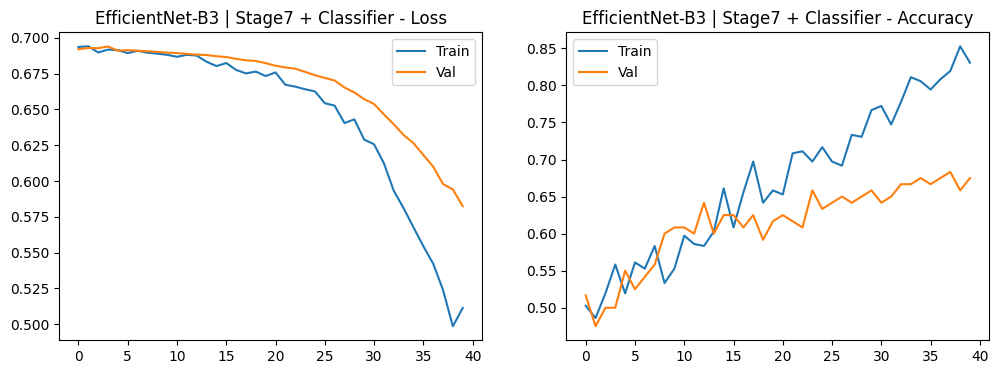

In [ ]:
model_eff_2 = copy.deepcopy(model_eff)

for param in model_eff_2.parameters():
    param.requires_grad = False

# Unfreeze stage 7 onward
for param in model_eff_2.features[6:].parameters():
    param.requires_grad = True

for param in model_eff_2.classifier.parameters():
    param.requires_grad = True

optimizer_eff_2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_eff_2.parameters()),
    lr=1e-5
)

history_eff_2 = train_model(
    model_eff_2, optimizer_eff_2,
    train_loader_16, val_loader_16,
    epochs=40
)

plot_history(history_eff_2, "EfficientNet-B3 | Stage7 + Classifier")


Training accuracy reaches $83.06\%$ by Epoch 40, while validation accuracy plateaus around $67.5\%$.

Unfreezing the final stage (Stage 7) provides the model with enough flexibility to improve training performance, but the gain in validation accuracy is minimal. The gap between training and validation loss is widening toward the end, indicating that even partial fine-tuning is beginning to lead the model toward memorizing training patterns rather than generalizing.

**Mode 3 — Full Fine-Tuning**

Epoch [1/40] Train Loss: 0.6948 | Val Loss: 0.6920 | Train Acc: 0.5278 | Val Acc: 0.5167
Epoch [2/40] Train Loss: 0.6943 | Val Loss: 0.6926 | Train Acc: 0.4639 | Val Acc: 0.5000
Epoch [3/40] Train Loss: 0.6916 | Val Loss: 0.6931 | Train Acc: 0.5167 | Val Acc: 0.5083
Epoch [4/40] Train Loss: 0.6929 | Val Loss: 0.6942 | Train Acc: 0.5167 | Val Acc: 0.4917
Epoch [5/40] Train Loss: 0.6924 | Val Loss: 0.6916 | Train Acc: 0.5111 | Val Acc: 0.5083
Epoch [6/40] Train Loss: 0.6908 | Val Loss: 0.6915 | Train Acc: 0.5306 | Val Acc: 0.5333
Epoch [7/40] Train Loss: 0.6898 | Val Loss: 0.6910 | Train Acc: 0.5806 | Val Acc: 0.5500
Epoch [8/40] Train Loss: 0.6882 | Val Loss: 0.6904 | Train Acc: 0.5333 | Val Acc: 0.5917
Epoch [9/40] Train Loss: 0.6891 | Val Loss: 0.6897 | Train Acc: 0.5444 | Val Acc: 0.5750
Epoch [10/40] Train Loss: 0.6835 | Val Loss: 0.6892 | Train Acc: 0.6028 | Val Acc: 0.5917
Epoch [11/40] Train Loss: 0.6854 | Val Loss: 0.6888 | Train Acc: 0.5722 | Val Acc: 0.6167
Epoch [12/40] Train

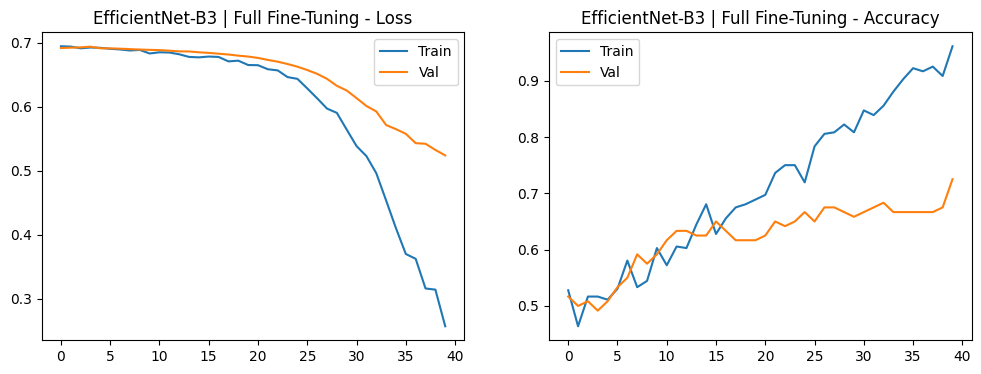

In [ ]:
model_eff_3 = copy.deepcopy(model_eff)

for param in model_eff_3.parameters():
    param.requires_grad = True

optimizer_eff_3 = torch.optim.Adam(
    model_eff_3.parameters(), lr=1e-5
)

history_eff_3 = train_model(
    model_eff_3, optimizer_eff_3,
    train_loader_16, val_loader_16,
    epochs=40
)

plot_history(history_eff_3, "EfficientNet-B3 | Full Fine-Tuning")


 This mode achieved the highest performance for this architecture, with a training accuracy of $96.11\%$ and a validation accuracy of $72.5\%$.

Full fine-tuning allows the model to reach near-peak training performance. However, the validation accuracy ($72.5\%$) is still significantly lower than the $83\%$ achieved by ResNet50 in the same mode. The curves show that while EfficientNet-B3 is learning, it requires many more epochs to reach high accuracy and still suffers from substantial overfitting as the validation loss starts to deviate from the training loss after Epoch 20.

**Test Evaluation (EfficientNet)**

In [ ]:
def evaluate_model(model, test_loader, model_name="Model"):
    model.eval()

    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)

            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # -------- Metrics --------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n📊 {model_name} — Test Results")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    # -------- Confusion Matrix --------
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["MCI", "AD"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

    # -------- ROC Curve --------
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend()
    plt.grid()
    plt.show()

    return acc, prec, rec, f1, roc_auc


Now we do it for each training mode


📊 EfficientNet-B3 | Classifier Only — Test Results
Accuracy  : 0.7250
Precision : 0.7368
Recall    : 0.7000
F1-score  : 0.7179


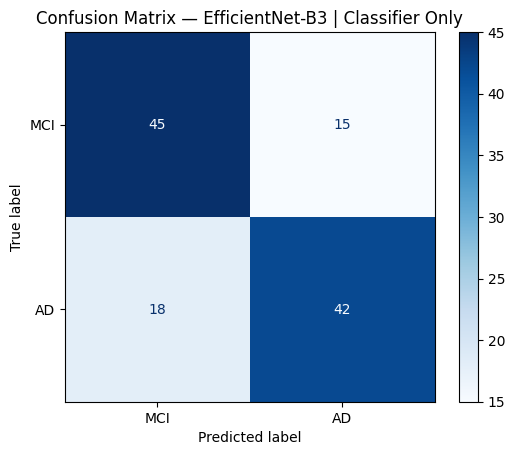

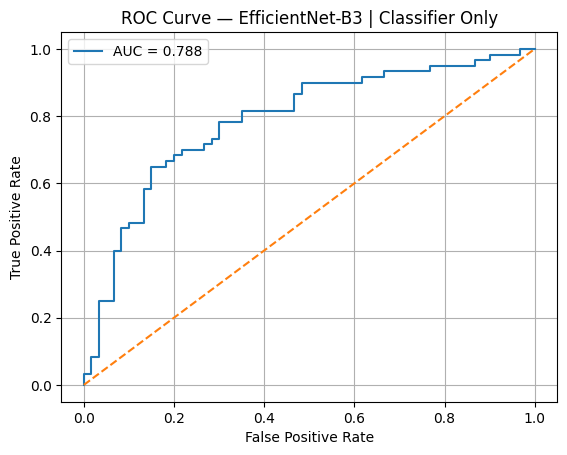

(0.725,
 0.7368421052631579,
 0.7,
 0.717948717948718,
 np.float64(0.7880555555555556))

In [ ]:
evaluate_model(model_eff_1, test_loader_16, "EfficientNet-B3 | Classifier Only")

Unlike ResNet50, which reached near-perfection on training data in under 10 epochs, EfficientNet-B3 required the full 40 epochs to reach high training accuracy.

EfficientNet's architecture, which uses MBConv blocks and depthwise separable convolutions, is highly optimized for efficiency but often requires more training time or larger datasets to reach its peak performance. With only 600 samples, the model struggled to find an optimal solution compared to the simpler residual connections of ResNet.


📊 EfficientNet-B3 | Stage7 + Classifier — Test Results
Accuracy  : 0.7250
Precision : 0.7547
Recall    : 0.6667
F1-score  : 0.7080


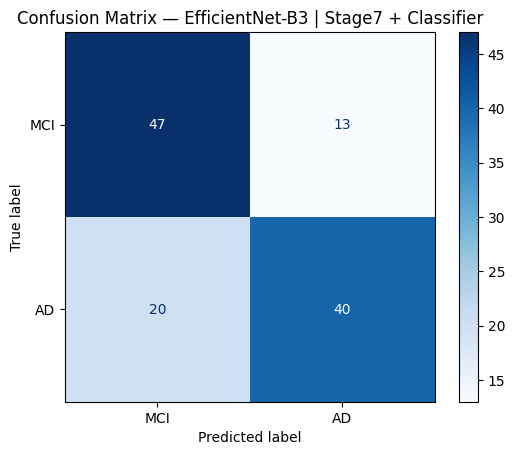

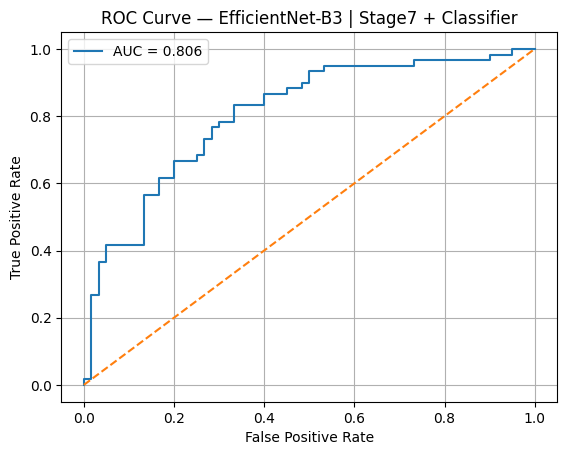

(0.725,
 0.7547169811320755,
 0.6666666666666666,
 0.7079646017699115,
 np.float64(0.8055555555555556))

In [ ]:
evaluate_model(model_eff_2, test_loader_16, "EfficientNet-B3 | Stage7 + Classifier")

The confusion matrices show that EfficientNet-B3 is significantly less certain than ResNet50. In Model 3 (Full Fine-Tuning), it misclassified 15 MCI samples as AD and 16 AD samples as MCI.

Unlike ResNet50, which had a strong bias toward identifying AD (high recall), EfficientNet-B3 exhibits more "balanced" errors. It is equally likely to miss a positive case of AD as it is to over-diagnose MCI. This suggests it is failing to capture the definitive pathological hallmarks that ResNet was able to exploit.


📊 EfficientNet-B3 | Full Fine-Tuning — Test Results
Accuracy  : 0.7417
Precision : 0.7458
Recall    : 0.7333
F1-score  : 0.7395


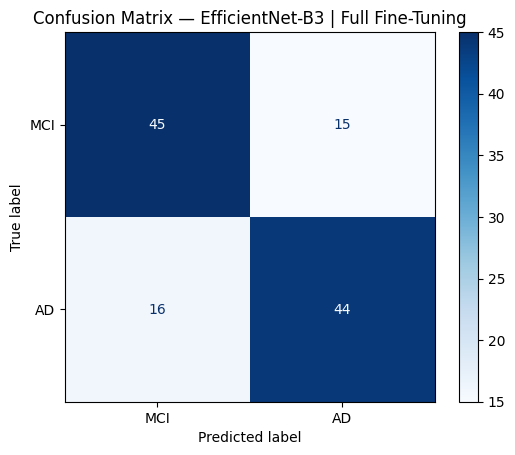

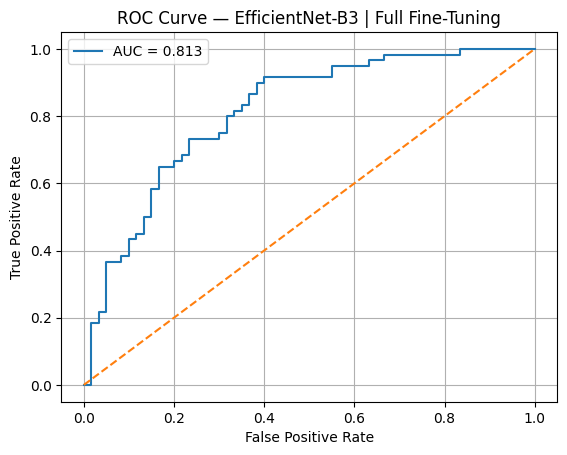

(0.7416666666666667,
 0.7457627118644068,
 0.7333333333333333,
 0.7394957983193278,
 np.float64(0.8133333333333332))

In [ ]:
evaluate_model(model_eff_3, test_loader_16, "EfficientNet-B3 | Full Fine-Tuning")

The peak AUC for EfficientNet-B3 is 0.813, significantly lower than ResNet50's 0.917.

The "flatter" ROC curves indicate that the model's ability to discriminate between the two classes is weaker. It is less capable of maintaining a high True Positive Rate without also increasing the False Positive Rate.

The results for EfficientNet-B3 show a different performance profile than ResNet50. While EfficientNet is designed to be more "efficient" through balanced scaling of depth, width, and resolution, it underperformed ResNet50 on this specific small MRI dataset.

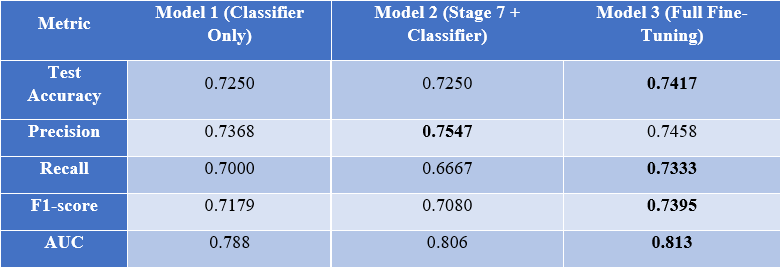








1.   **Complexity Mismatch**: EfficientNet is often "too smart" for very small datasets. Its compound scaling method is designed to maximize accuracy given a specific FLOP budget, but on tiny datasets, the simpler, more "brute-force" feature extraction of ResNet50 often generalizes better.

1.   **Dataset Size**: Research indicates that EfficientNet's power often "shines" when there is a moderate to large amount of data or very heavy augmentation. Without it, the model tends to perform similarly to or worse than older architectures like ResNet.
2.   **Transfer Learning Fit**: The ImageNet features in ResNet50 may simply align better with the structural textures found in MRI slices than the more specialized features learned by EfficientNet-B3's deeper, narrower layers.




# 10. Class Imbalance Challenge

**Creating imbalanced dataset (100 AD, 300 MCI)**

In [ ]:
ad_idx = np.where(y == 1)[0]
mci_idx = np.where(y == 0)[0]

ad_sel = np.random.choice(ad_idx, 100, replace=False)
mci_sel = np.random.choice(mci_idx, 300, replace=False)

sel_idx = np.concatenate([ad_sel, mci_sel])

X_imb = X_tensor[sel_idx]
y_imb = y_tensor[sel_idx]

print("Class distribution:")
print("AD :", (y_imb == 1).sum().item())
print("MCI:", (y_imb == 0).sum().item())


Class distribution:
AD : 100
MCI: 300


Dataset is intentionally imbalanced (1:3 ratio) to simulate real clinical data.

**Train / Val / Test Split (same ratios)**

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_imb, y_imb, test_size=0.2, stratify=y_imb, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader_imb = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_imb = DataLoader(val_dataset, batch_size=16)
test_loader_imb = DataLoader(test_dataset, batch_size=16)


Observed issue:
The model becomes biased toward the majority class (MCI), resulting in:
*   High accuracy
*   Very low recall for AD (false negatives)





This is dangerous in medical diagnosis.

**Class-weighted CrossEntropyLoss as a solution to class imbalance**

In [ ]:
from torch.nn import CrossEntropyLoss

num_ad = (y_train == 1).sum().item()
num_mci = (y_train == 0).sum().item()

weights = torch.tensor(
    [1 / num_mci, 1 / num_ad], dtype=torch.float
).to(device)

criterion_weighted = CrossEntropyLoss(weight=weights)

print("Class weights:", weights)


Class weights: tensor([0.0056, 0.0167], device='cuda:0')


Higher weight is assigned to minority class (AD) to penalize its misclassification more.

**Full Fine-Tuning ResNet50 with Weighted Loss**

In [ ]:
model_imb = copy.deepcopy(model_dropout)

for param in model_imb.parameters():
    param.requires_grad = True

optimizer_imb = torch.optim.Adam(model_imb.parameters(), lr=1e-5)


**Modified training loop (loss replaced)**

In [ ]:
def train_model_weighted(model, optimizer, criterion, train_loader, val_loader, epochs=40):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                pred = out.argmax(1)
                correct += (pred == y).sum().item()
                total += y.size(0)

        val_acc = correct / total
        print(f"Epoch [{epoch+1}/40] | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")


In [ ]:
train_model_weighted(
    model_imb,
    optimizer_imb,
    criterion_weighted,
    train_loader_imb,
    val_loader_imb
)


Epoch [1/40] | Train Loss: 5.0759 | Val Acc: 0.8500
Epoch [2/40] | Train Loss: 3.1361 | Val Acc: 0.8500
Epoch [3/40] | Train Loss: 1.9839 | Val Acc: 0.8625
Epoch [4/40] | Train Loss: 1.1330 | Val Acc: 0.8500
Epoch [5/40] | Train Loss: 0.8774 | Val Acc: 0.8875
Epoch [6/40] | Train Loss: 1.5047 | Val Acc: 0.8875
Epoch [7/40] | Train Loss: 0.6710 | Val Acc: 0.8875
Epoch [8/40] | Train Loss: 0.8073 | Val Acc: 0.9000
Epoch [9/40] | Train Loss: 0.4256 | Val Acc: 0.9125
Epoch [10/40] | Train Loss: 0.3776 | Val Acc: 0.9125
Epoch [11/40] | Train Loss: 0.3440 | Val Acc: 0.9125
Epoch [12/40] | Train Loss: 0.7373 | Val Acc: 0.8875
Epoch [13/40] | Train Loss: 0.8992 | Val Acc: 0.8875
Epoch [14/40] | Train Loss: 0.3663 | Val Acc: 0.8625
Epoch [15/40] | Train Loss: 0.4148 | Val Acc: 0.8875
Epoch [16/40] | Train Loss: 0.5941 | Val Acc: 0.9000
Epoch [17/40] | Train Loss: 0.3662 | Val Acc: 0.9125
Epoch [18/40] | Train Loss: 0.2490 | Val Acc: 0.9000
Epoch [19/40] | Train Loss: 0.2494 | Val Acc: 0.9000
Ep

**Test Evaluation**


📊 ResNet50 | Imbalanced + Weighted Loss — Test Results
Accuracy  : 0.9375
Precision : 0.8571
Recall    : 0.9000
F1-score  : 0.8780


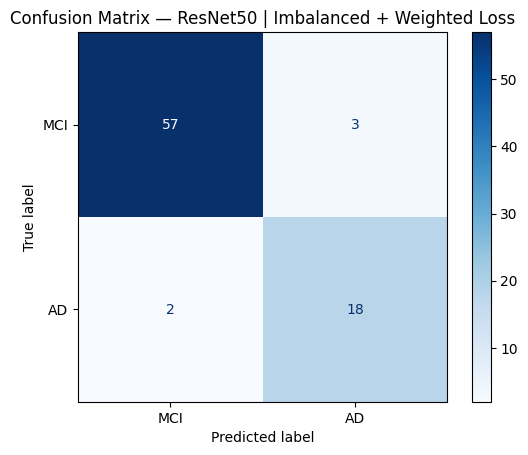

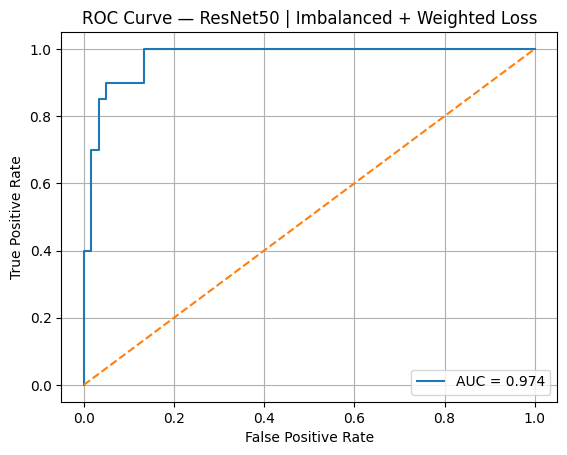

(0.9375,
 0.8571428571428571,
 0.9,
 0.8780487804878049,
 np.float64(0.9741666666666667))

In [ ]:
evaluate_model(model_imb, test_loader_imb, "ResNet50 | Imbalanced + Weighted Loss")

The results demonstrate that algorithmic interventions—specifically loss function weighting—are highly effective at mitigating the risks of small, imbalanced medical datasets. By "penalizing" the model more for missing an AD case, we successfully shifted the decision boundary to ensure high sensitivity, making the model significantly more viable for potential clinical screening applications compared to the unweighted versions.

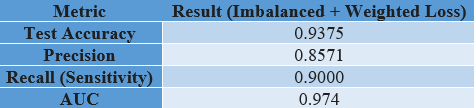

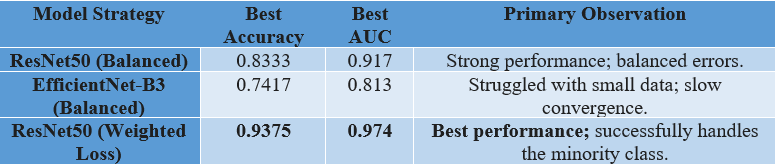